### Student ID: 24072610
### Name: Mokhtar Farvaresh
### Programme: MSc Data Science

## **Section 1**: Explaining, Preprocessing, Combining and other Investigations of the

- **1-1 Importing Libraries & Tools**

In [1]:
# Import necessary libraries and Tools
import pyspark

from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import OrderedDict

from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.ml.stat import Correlation
from pyspark.sql.types import IntegerType,BooleanType,DateType,FloatType, StringType

- **1-2 Pyspark Session**

  - Below config settings are optimized for local development, also we can enable more features as CPU core used and memory usage in this session

In [5]:
spark = SparkSession.builder \
    .appName("Spotify_Data_Analysis") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print(f"Python Version: {spark.sparkContext.pythonVer}")

TypeError: 'JavaPackage' object is not callable

- **1-3 Loading Data and Display Basic information**

  - tracks.csv , artists.csv

In [5]:
# ============================================
# SECTION 2: LOADING THE DATA
# ============================================

# Read the CSV file
# For large datasets, Spark reads data lazily - it doesn't load everything at once
tracks_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("tracks.csv")

# Also load artists data for potential joins later
artists_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("artists.csv")

# Display basic information
print(f"Tracks DataFrame Schema:")
tracks_df.printSchema()

print(f"\nNumber of tracks: {tracks_df.count()}")
print(f"Number of columns: {len(tracks_df.columns)}")

# Show first few rows
print("\nFirst 5 rows:")
tracks_df.show(5, truncate=False)

Tracks DataFrame Schema:
root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- id_artists: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- key: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- liveness: string (nullable = true)
 |-- valence: string (nullable = true)
 |-- tempo: string (nullable = true)
 |-- time_signature: string (nullable = true)


Number of tracks: 586672
Number of columns: 20

First 5 rows:
+----------------------+-----------------------------------+----------+-----------+--------+----

- **1-4 Data Exploration and Quality Checks**

In [7]:
# Check for missing values in each column
print("\n=== Missing Values Analysis ===")
missing_counts = []
for col_name in tracks_df.columns:
    missing_count = tracks_df.filter(col(col_name).isNull() | (col(col_name) == "")).count()
    total_count = tracks_df.count()
    missing_percent = (missing_count / total_count) * 100
    missing_counts.append((col_name, missing_count, missing_percent))

# Create a DataFrame from missing counts for better visualization
missing_df = spark.createDataFrame(missing_counts, ["Column", "Missing_Count", "Missing_Percentage"])
missing_df.orderBy(col("Missing_Percentage").desc()).show()

# Check data types
print("\n=== Data Types ===")
for field in tracks_df.schema.fields:
    print(f"{field.name}: {field.dataType}")


=== Missing Values Analysis ===
+----------------+-------------+--------------------+
|          Column|Missing_Count|  Missing_Percentage|
+----------------+-------------+--------------------+
|            name|           71|0.012102162707611748|
|             key|           12|0.002045435950582...|
|      id_artists|           12|0.002045435950582...|
|        loudness|           12|0.002045435950582...|
|    release_date|           12|0.002045435950582...|
|            mode|           12|0.002045435950582...|
|    danceability|           12|0.002045435950582...|
|     speechiness|           12|0.002045435950582...|
|          energy|           12|0.002045435950582...|
|    acousticness|           12|0.002045435950582...|
|instrumentalness|           12|0.002045435950582...|
|        liveness|           12|0.002045435950582...|
|         valence|           12|0.002045435950582...|
|           tempo|           12|0.002045435950582...|
|  time_signature|           12|0.002045435950582

- **1-5 Data Cleaning and Preprocessing**

  - *Step 1: Casting the Columns Types*

In [19]:
artists_df = artists_df.withColumn("followers", artists_df.followers.cast(IntegerType())) \
         .withColumn("popularity", artists_df.popularity.cast(IntegerType()))

tracks_df = tracks_df.withColumn("duration_ms", tracks_df.duration_ms.cast(IntegerType())) \
         .withColumn("popularity", tracks_df.popularity.cast(IntegerType())) \
         .withColumn("explicit", tracks_df.explicit.cast(IntegerType())) \
         .withColumn("release_date", tracks_df.release_date.cast(DateType())) \
         .withColumn("danceability", tracks_df.danceability.cast(FloatType())) \
         .withColumn("energy", tracks_df.energy.cast(FloatType())) \
         .withColumn("key", tracks_df.key.cast(IntegerType())) \
         .withColumn("loudness", tracks_df.loudness.cast(FloatType())) \
         .withColumn("mode", tracks_df.mode.cast(IntegerType())) \
         .withColumn("speechiness", tracks_df.speechiness.cast(FloatType())) \
         .withColumn("acousticness", tracks_df.acousticness.cast(FloatType())) \
         .withColumn("instrumentalness", tracks_df.instrumentalness.cast(FloatType())) \
         .withColumn("liveness", tracks_df.liveness.cast(FloatType())) \
         .withColumn("valence", tracks_df.valence.cast(FloatType())) \
         .withColumn("tempo", tracks_df.tempo.cast(FloatType())) \
         .withColumn("time_signature", tracks_df.time_signature.cast(IntegerType()))

  - *Step 2: Handling 'artists' and 'id_artists' column which are stored as string but contains list*



In [20]:
print("\n______Starting Data Cleaning______")

# We need to parse the string representation of lists and save them as actual strings at the end
def clean_string_array(col_name):
    """Clean string representation of arrays by removing brackets and quotes"""
    return regexp_replace(
        regexp_replace(
            regexp_replace(col(col_name), "\\[", ""),  # Remove [
            "\\]", ""                                   # Remove ]
        ),
        "'", ""                                         # Remove quotes
    )

# Clean artists and id_artists columns
tracks_clean = tracks_df \
    .withColumn("artists_cleaned", clean_string_array("artists")) \
    .withColumn("id_artists_cleaned", clean_string_array("id_artists"))


# Show first few rows
print("\nFirst 5 rows:")
tracks_clean.show(5, truncate=False)


print("\nData Types\n")
for field in tracks_clean.schema.fields:
    print(f"{field.name}: {field.dataType}")


______Starting Data Cleaning______

First 5 rows:
+----------------------+-----------------------------------+----------+-----------+--------+-------------------+--------------------------+------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+---------------+----------------------+
|id                    |name                               |popularity|duration_ms|explicit|artists            |id_artists                |release_date|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|tempo  |time_signature|artists_cleaned|id_artists_cleaned    |
+----------------------+-----------------------------------+----------+-----------+--------+-------------------+--------------------------+------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+---------------+----------------------+
|35iwgR4jXetI

  - *Step 3: Handle Date Formatting*

In [35]:
# Step 2: Handle date formatting
# Parse release_date to proper date type (some dates might be year-only)
tracks_clean = tracks_clean.withColumn(
    "release_date_parsed",
    when(length(col("release_date")) == 4,
         concat(col("release_date"), lit("-01-01")))  # If only year, assume Jan 1
    .otherwise(col("release_date"))
)

# Filter out problematic dates starting with '+'
tracks_clean = tracks_clean.filter(~col("release_date_parsed").startswith("+"))

# Convert to date type
tracks_clean = tracks_clean.withColumn(
    "release_date_formatted",
    to_date(col("release_date_parsed"), "yyyy-MM-dd")
).withColumn(
    "release_date_formatted",
    coalesce(
        col("release_date_formatted"),
        to_date(col("release_date_parsed"), "M/d/yyyy"),  # Handle different format
        to_date(col("release_date_parsed"), "MM/dd/yyyy")
    )
)

# Extract year, month, and decade for analysis
tracks_clean = tracks_clean \
    .withColumn("release_year", year(col("release_date_formatted"))) \
    .withColumn("release_month", month(col("release_date_formatted"))) \
    .withColumn("release_decade", (floor(col("release_year") / 10) * 10).cast(IntegerType()))

   - *Step 4: Convert duration from milliseconds to minutes*

In [22]:
# Convert duration from milliseconds to minutes
tracks_clean = tracks_clean.withColumn(
    "duration_minutes",
    round(col("duration_ms") / 60000, 2)  # Convert to minutes with 2 decimal places
)

- *Step 5: Create categorical variables for audio features*

In [23]:
# This helps in analysis and visualization
tracks_clean = tracks_clean \
    .withColumn("energy_category",
        when(col("energy") < 0.3, "Low")
        .when(col("energy") < 0.7, "Medium")
        .otherwise("High")
    ) \
    .withColumn("tempo_category",
        when(col("tempo") < 100, "Slow")
        .when(col("tempo") < 130, "Medium")
        .otherwise("Fast")
    ) \
    .withColumn("valence_category",
        when(col("valence") < 0.3, "Sad")
        .when(col("valence") < 0.7, "Neutral")
        .otherwise("Happy")
    )


  - *Step 6: Handle missing values for audio features*

In [24]:
# Step 5: Handle missing values for audio features
# For numeric audio features, we'll use median imputation
numeric_features = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Calculate medians for imputation
medians = {}
for feature in numeric_features:
    median_value = tracks_clean.select(percentile_approx(col(feature), 0.5)).collect()[0][0]
    medians[feature] = median_value
    print(f"Median {feature}: {median_value}")

# Apply median imputation
for feature, median_val in medians.items():
    tracks_clean = tracks_clean.withColumn(
        feature,
        when(col(feature).isNull(), median_val).otherwise(col(feature))
    )

Median danceability: 0.578000009059906
Median energy: 0.550000011920929
Median loudness: -9.190999984741211
Median speechiness: 0.04430000111460686
Median acousticness: 0.4169999957084656
Median instrumentalness: 2.5200000891345553e-05
Median liveness: 0.13899999856948853
Median valence: 0.5640000104904175
Median tempo: 117.1760025024414


## **Section 2:** Exploratory Data Analysis (EDA)

- **2-1  Basic Statistics for Numeric Columns**

In [39]:
print("\n1. Summary Statistics for Audio Features:\n")
tracks_clean.select(numeric_features).describe().show()



1. Summary Statistics for Audio Features:

+-------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+
|summary|      danceability|             energy|           loudness|        speechiness|       acousticness|   instrumentalness|           liveness|           valence|             tempo|
+-------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+
|  count|            583363|             583363|             583363|             583363|             583363|             583363|             583363|            583363|            583363|
|   mean|0.5644245444470346| 0.5433663551717034|-10.176465481952196|0.10494762769286264| 0.4479695263260765|0.11321651484078142|0.21380841902586764| 0.553563896768519|118.53791418629149|
| stddev|0.1655323008

- **2-2 Popularity Distribution**

In [40]:

print("\n2. Popularity Distribution:\n")
popularity_stats = tracks_clean.select(
    mean("popularity").alias("avg_popularity"),
    stddev("popularity").alias("std_popularity"),
    min("popularity").alias("min_popularity"),
    max("popularity").alias("max_popularity"),
    expr("percentile_approx(popularity, 0.5)").alias("median_popularity")
).collect()[0]

for stat in popularity_stats.asDict():
    print(f"{stat}: {popularity_stats[stat]:.2f}")



2. Popularity Distribution:

avg_popularity: 27.65
std_popularity: 18.35
min_popularity: 0.00
max_popularity: 100.00
median_popularity: 27.00


  - **2-3 Temporal Analysis**

In [41]:
print("\n3. Tracks by Decade:\n")

decade_counts = tracks_clean \
    .filter(col("release_decade").isNotNull()) \
    .groupBy("release_decade") \
    .agg(
        count("*").alias("track_count"),
        avg("popularity").alias("avg_popularity"),
        avg("energy").alias("avg_energy"),
        avg("valence").alias("avg_valence")
    ) \
    .orderBy("release_decade")

decade_counts.show()


3. Tracks by Decade:

+--------------+-----------+------------------+-------------------+------------------+
|release_decade|track_count|    avg_popularity|         avg_energy|       avg_valence|
+--------------+-----------+------------------+-------------------+------------------+
|          1900|          1|              19.0| 0.7910000085830688|0.9559999704360962|
|          1920|       7601|1.1393237731877384| 0.2812560004310782| 0.599909460633175|
|          1930|      12952| 2.120830759728227| 0.3067627750885171|0.5725603829539665|
|          1940|      17772|1.7986158001350439|0.26853156766032454|0.5043820752737628|
|          1950|      33977| 8.597845601436266| 0.3028147129145215|0.5054985303450622|
|          1960|      46874|17.949374919998295| 0.4063387456165305|0.5639647559463724|
|          1970|      61610|24.181626359357246| 0.5026020538726775|0.5808344535585444|
|          1980|      82132| 25.67711732333317| 0.5506233902370259|0.5806300653002734|
|          1990|    

   - **2-4 Audio Feature Correlations**

In [42]:
# As PySpark doesn't have built-in correlation matrix, so we'll calculate only key correlations
print("\n4. Key Audio Feature Correlations:\n")

correlations = []
feature_pairs = [
    ("energy", "loudness"),
    ("energy", "acousticness"),
    ("danceability", "valence"),
    ("speechiness", "instrumentalness")
]

for feat1, feat2 in feature_pairs:
    corr_value = tracks_clean.stat.corr(feat1, feat2)
    correlations.append((feat1, feat2, corr_value))
    print(f"Correlation between {feat1} and {feat2}: {corr_value:.3f}")


4. Key Audio Feature Correlations:

Correlation between energy and loudness: 0.763
Correlation between energy and acousticness: -0.714
Correlation between danceability and valence: 0.524
Correlation between speechiness and instrumentalness: -0.102


- **2-5 Most Common Artists (from cleaned artist column)**

In [49]:
print("\n5. Most Common Artist by Decade (Last 100 Years):\n")

# Define a window specification to partition by decade and order by track count
window_spec_decade = Window.partitionBy("release_decade").orderBy(col("track_count").desc())

# Calculate track counts per artist per decade and rank them
artist_decade_ranked = tracks_clean \
    .select(explode(split(col("artists_cleaned"), ", ")).alias("artist"), col("release_decade")) \
    .filter(col("release_decade").isNotNull()) \
    .groupBy("release_decade", "artist") \
    .agg(count("*").alias("track_count")) \
    .withColumn("rank", rank().over(window_spec_decade))

# Filter for the top 1 artist in each decade and filter for last 10 decades
top_artists_by_decade = artist_decade_ranked \
    .filter(col("rank") <= 1) \
    .filter(col("release_decade") >= 2020 - 100) \
    .orderBy("release_decade", "rank")

# results
top_artists_by_decade.show(20, truncate=False)


5. Most Common Artist by Decade (Last 100 Years):

+--------------+------------------------+-----------+----+
|release_decade|artist                  |track_count|rank|
+--------------+------------------------+-----------+----+
|1920          |Francisco Canaro        |975        |1   |
|1930          |Tadeusz Dolega Mostowicz|838        |1   |
|1940          |Igor Stravinsky         |432        |1   |
|1950          |Lata Mangeshkar         |808        |1   |
|1960          |Mohammed Rafi           |714        |1   |
|1970          |Tintin                  |573        |1   |
|1980          |TKKG Retro-Archiv       |1647       |1   |
|1990          |Die drei ???            |1600       |1   |
|2000          |Die drei ???            |293        |1   |
|2010          |Armin van Buuren        |520        |1   |
|2020          |J Balvin                |502        |1   |
+--------------+------------------------+-----------+----+



   - **2-6 Using pyspark to filter results**

In [56]:
# select only the songs released in 1985

from pyspark.sql.functions import year

tracks_clean.filter(year(tracks_clean['release_date_formatted']) == 1985) \
  .select('name', 'artists_cleaned','release_date_formatted') \
  .distinct() \
  .show(5, truncate=False)

+------------------------------------------------------+-------------------+----------------------+
|name                                                  |artists_cleaned    |release_date_formatted|
+------------------------------------------------------+-------------------+----------------------+
|Walking On Sunshine                                   |Katrina & The Waves|1985-01-01            |
|Never                                                 |Heart              |1985-07-06            |
|Cheeseburger In Paradise                              |Jimmy Buffett      |1985-01-01            |
|"Anyplace, Anywhere, Anytime - Special 12"" Dance Mix"|Nena               |1985-08-10            |
|Maureen                                               |Sade               |1985-11-04            |
+------------------------------------------------------+-------------------+----------------------+
only showing top 5 rows



## **Section 3:** Advanced Cleaning for Big Data Optimisation

In [51]:
# 1. Repartition based on a key column for better parallelism
# This is useful when you'll be doing many operations grouped by year
tracks_optimized = tracks_clean.repartition(200, "release_year")

# 2. Cache frequently used DataFrames
# This keeps the DataFrame in memory for faster repeated access
tracks_optimized.cache()
print(f"\nDataFrame cached. Partitions: {tracks_optimized.rdd.getNumPartitions()}")

# 3. Create a cleaned, analysis-ready dataset
# Select only necessary columns to reduce memory usage
analysis_columns = [
    "id", "name", "popularity", "duration_minutes", "explicit",
    "artists_cleaned", "release_year", "release_decade",
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "time_signature",
    "energy_category", "tempo_category", "valence_category"
]

tracks_final = tracks_optimized.select(analysis_columns)


DataFrame cached. Partitions: 200


## **Section 4:** Saved Cleaned Data

In [52]:
# Save as Parquet for efficient storage and faster reads
# Parquet is columnar format, perfect for analytics
output_path = "spotify_tracks_cleaned"

tracks_final.write \
    .mode("overwrite") \
    .partitionBy("release_decade") \
    .parquet(output_path)

print(f"\nCleaned data saved to: {output_path}")

# For CSV output (less efficient but more portable)
# tracks_final.coalesce(1).write.mode("overwrite").option("header", "true").csv("spotify_tracks_cleaned.csv")

# Data Summary

print("\nFinal Data Profile\n")
print(f"Total Tracks: {tracks_final.count()}")
print(f"Columns: {len(tracks_final.columns)}")
print(f"Memory Usage: ~{tracks_final.rdd.map(lambda x: len(str(x))).sum() / 1024 / 1024:.2f} MB")

# sample of cleaned data
print("\nSample of cleaned data:")
tracks_final.show(5)


Cleaned data saved to: spotify_tracks_cleaned

=== Final Data Profile ===
Total Tracks: 583363
Columns: 23
Memory Usage: ~315.74 MB

Sample of cleaned data:
+--------------------+---------------+----------+----------------+--------+--------------------+------------+--------------+-------------------+-------------------+---+-------------------+----+--------------------+------------------+--------------------+-------------------+-------------------+------------------+--------------+---------------+--------------+----------------+
|                  id|           name|popularity|duration_minutes|explicit|     artists_cleaned|release_year|release_decade|       danceability|             energy|key|           loudness|mode|         speechiness|      acousticness|    instrumentalness|           liveness|            valence|             tempo|time_signature|energy_category|tempo_category|valence_category|
+--------------------+---------------+----------+----------------+--------+-------------

## **Section 5:** Visualisations

  - **5-1 Visualisation setup**

In [53]:
# For visualisation, we'll convert small aggregated results to Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark.sql.window import Window

# style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

   - **5-2: Visualisation Function**

In [54]:
def plot_distribution(spark_df, column, title, bins=30):
    """
    Plot distribution of a numeric column
    spark_df: PySpark DataFrame
    column: column name to plot
    """
    # Collect data to Pandas (only for visualization)
    data = spark_df.select(column).filter(col(column).isNotNull()).toPandas()

    plt.figure(figsize=(10, 6))
    plt.hist(data[column], bins=bins, edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {title}', fontsize=16)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

def plot_correlation_heatmap(spark_df, features):
    """
    Create correlation heatmap for selected features
    """
    # Calculate correlation matrix
    corr_data = []
    for i, feat1 in enumerate(features):
        row = []
        for feat2 in features:
            if feat1 == feat2:
                row.append(1.0)
            else:
                corr = spark_df.stat.corr(feat1, feat2)
                row.append(corr)
        corr_data.append(row)

    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_data,
                xticklabels=features,
                yticklabels=features,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0)
    plt.title('Audio Features Correlation Matrix', fontsize=16)
    plt.tight_layout()
    plt.show()

   - **5-3 Music Characteristics Trends Over Decades**


=== Music Characteristics Trends Over Decades ===


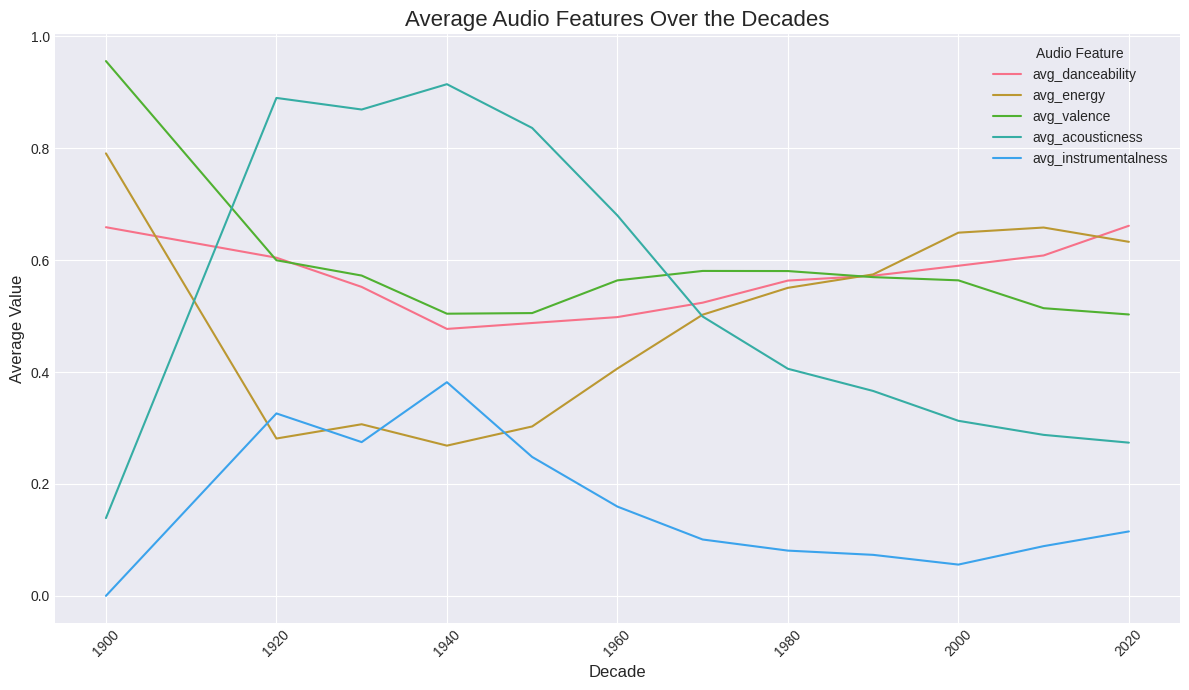

In [61]:
# Aggregate average audio features by decade
decade_audio_features = tracks_clean \
    .filter(col("release_decade").isNotNull()) \
    .groupBy("release_decade") \
    .agg(
        avg("danceability").alias("avg_danceability"),
        avg("energy").alias("avg_energy"),
        avg("valence").alias("avg_valence"),
        avg("acousticness").alias("avg_acousticness"),
        avg("instrumentalness").alias("avg_instrumentalness")
    ) \
    .orderBy("release_decade") \
    .toPandas()

# Melt the DataFrame for seaborn line plot
df_melted = pd.melt(decade_audio_features,
                    id_vars=['release_decade'],
                    value_vars=['avg_danceability', 'avg_energy', 'avg_valence', 'avg_acousticness', 'avg_instrumentalness'],
                    var_name='Audio Feature',
                    value_name='Average Value')

# Plot the trends using seaborn
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_melted, x='release_decade', y='Average Value', hue='Audio Feature')
plt.title('Average Audio Features Over the Decades', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

   - **5-4 Audio Feature Analysis Trough visualisations**

=== Audio Features Analysis ===


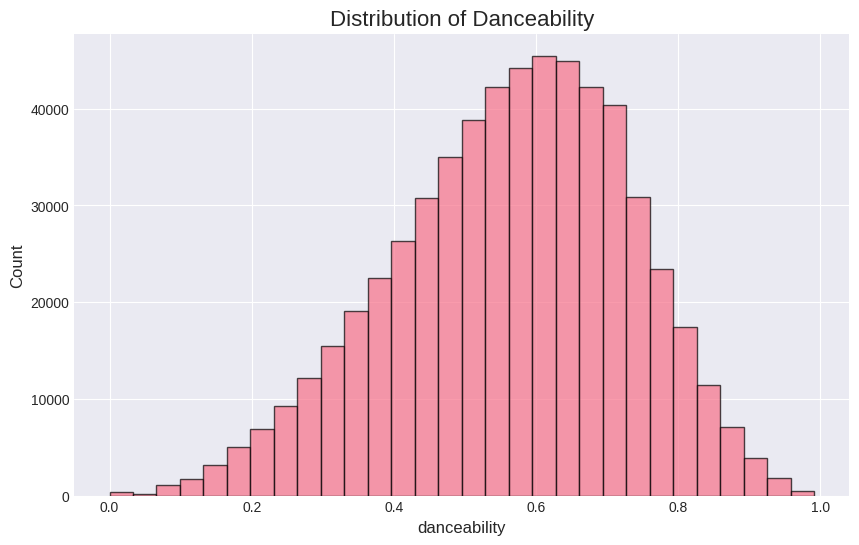

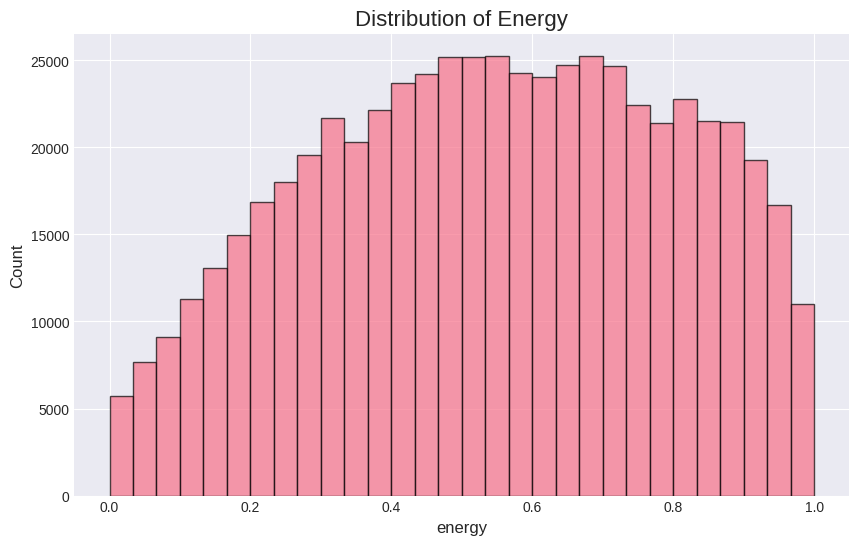

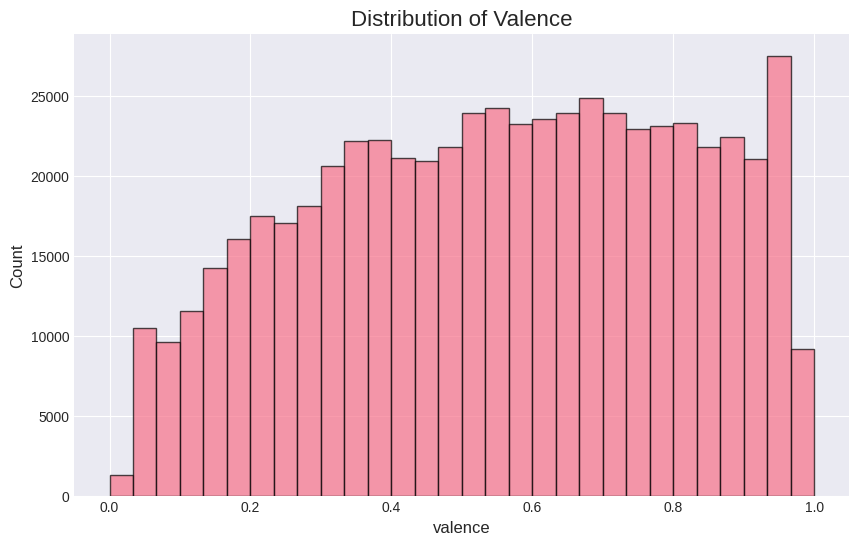

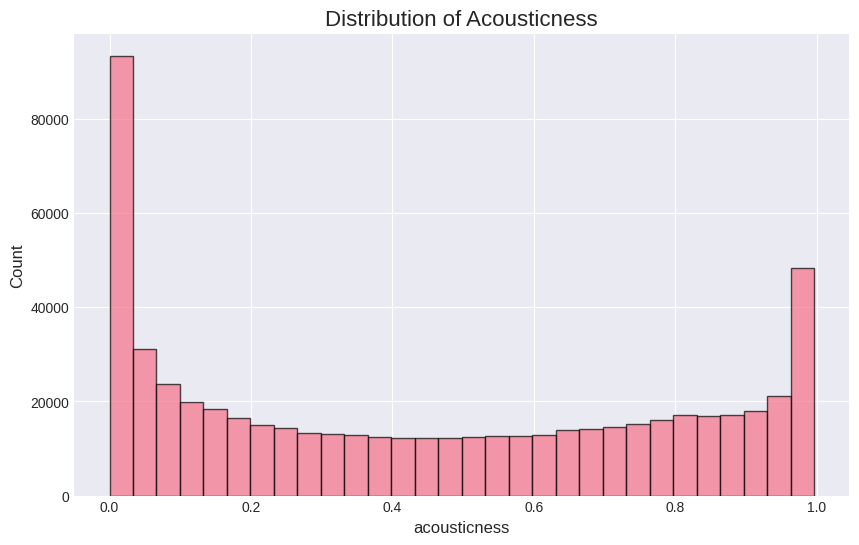

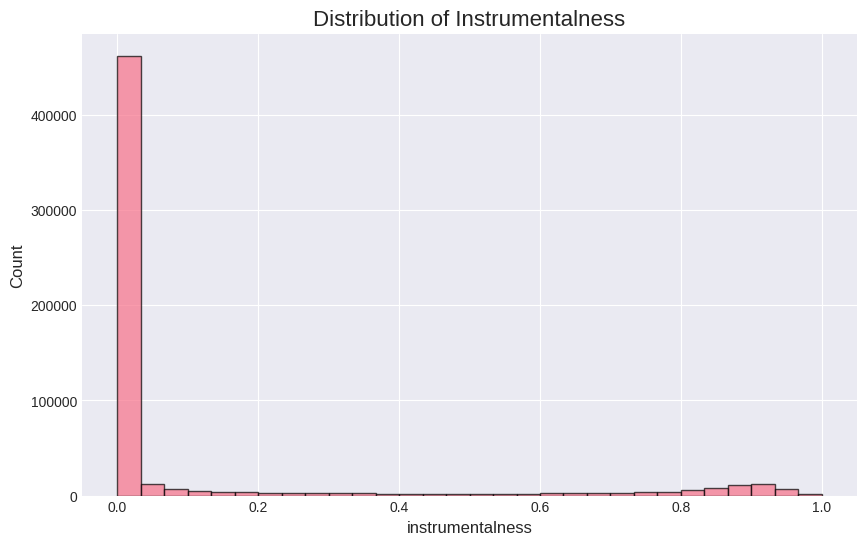

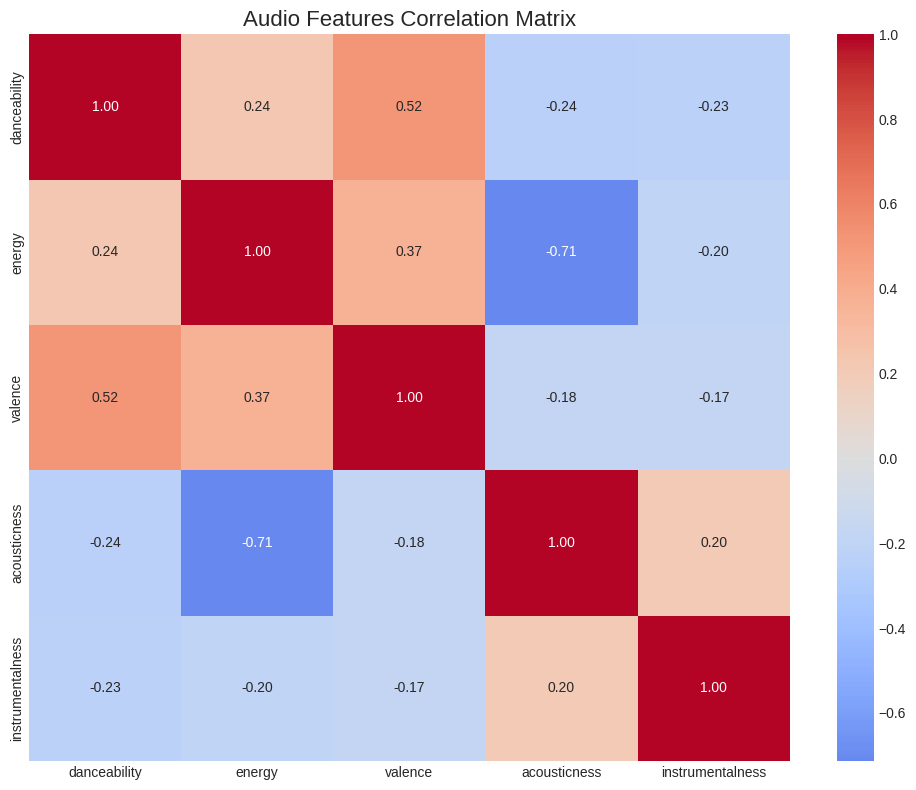

In [55]:
# Select key audio features
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness']

# Plot distributions
for feature in audio_features:
    plot_distribution(tracks_clean, feature, feature.capitalize())

# Create correlation heatmap
plot_correlation_heatmap(tracks_clean, audio_features)


   - **5-5 Temporal Trends Analysis**


 Temporal Trends



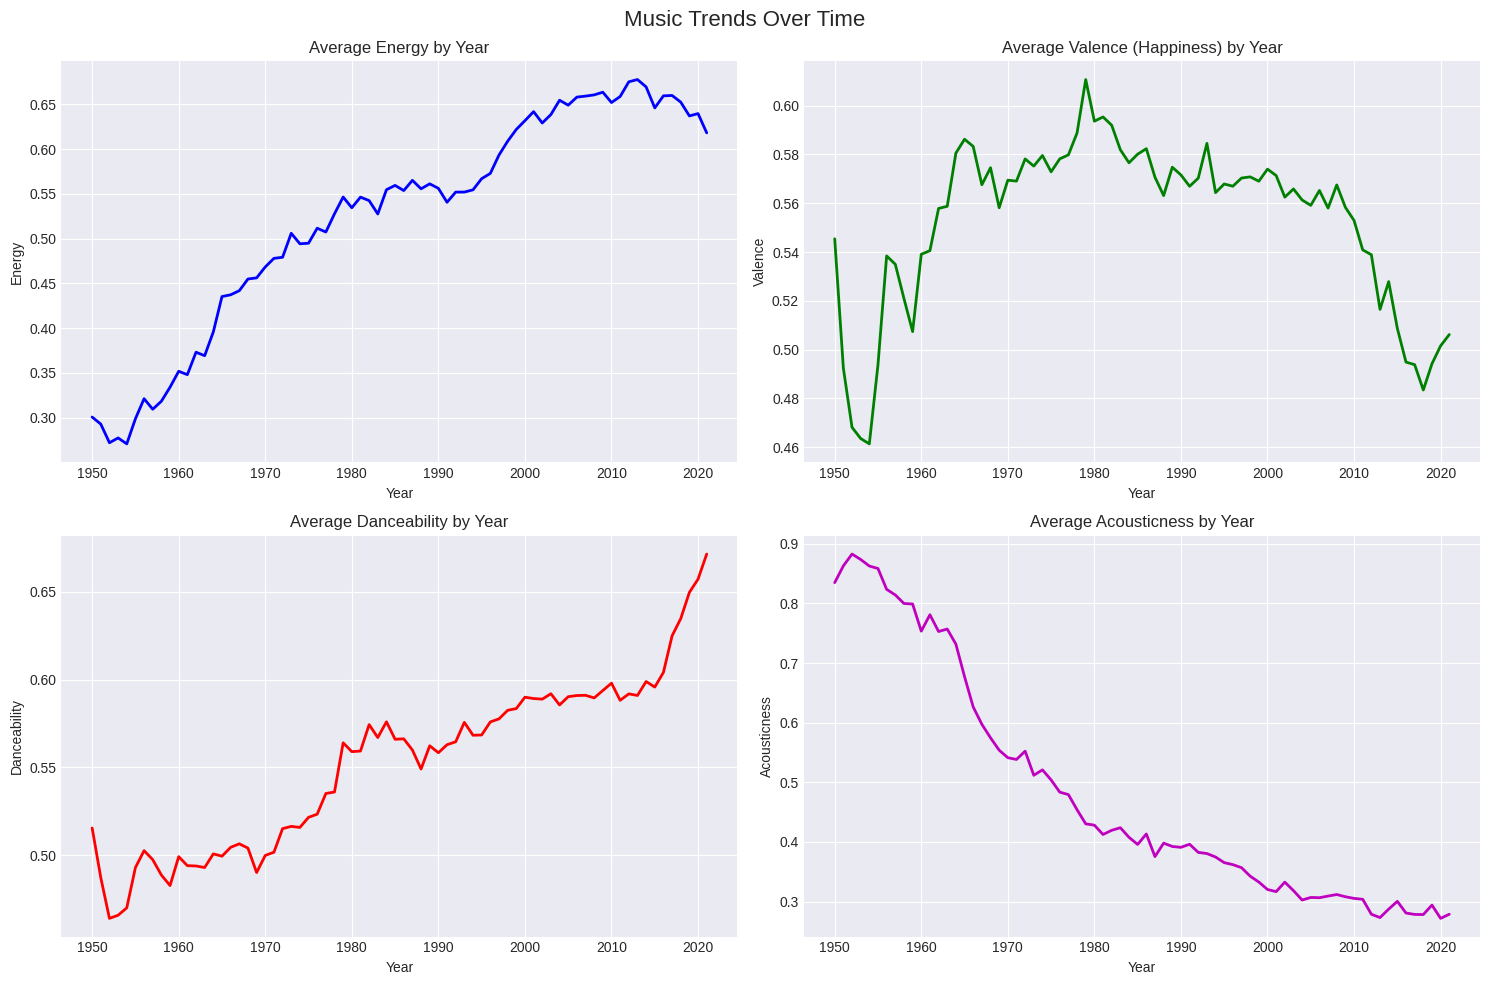

In [62]:
print("\n Temporal Trends:\n")

# Aggregate by year for trend analysis
yearly_trends = tracks_clean \
    .filter(col("release_year").between(1950, 2023)) \
    .groupBy("release_year") \
    .agg(
        avg("energy").alias("avg_energy"),
        avg("valence").alias("avg_valence"),
        avg("danceability").alias("avg_danceability"),
        avg("acousticness").alias("avg_acousticness"),
        count("*").alias("track_count")
    ) \
    .orderBy("release_year") \
    .toPandas()

# Plot temporal trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Music Trends Over Time', fontsize=16)

# Energy trend
axes[0, 0].plot(yearly_trends['release_year'], yearly_trends['avg_energy'], 'b-', linewidth=2)
axes[0, 0].set_title('Average Energy by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Energy')

# Valence trend
axes[0, 1].plot(yearly_trends['release_year'], yearly_trends['avg_valence'], 'g-', linewidth=2)
axes[0, 1].set_title('Average Valence (Happiness) by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Valence')

# Danceability trend
axes[1, 0].plot(yearly_trends['release_year'], yearly_trends['avg_danceability'], 'r-', linewidth=2)
axes[1, 0].set_title('Average Danceability by Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Danceability')

# Acousticness trend
axes[1, 1].plot(yearly_trends['release_year'], yearly_trends['avg_acousticness'], 'm-', linewidth=2)
axes[1, 1].set_title('Average Acousticness by Year')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Acousticness')

plt.tight_layout()
plt.show()

   - **5-6 Popularity Analysis**


Popularity Analysis:



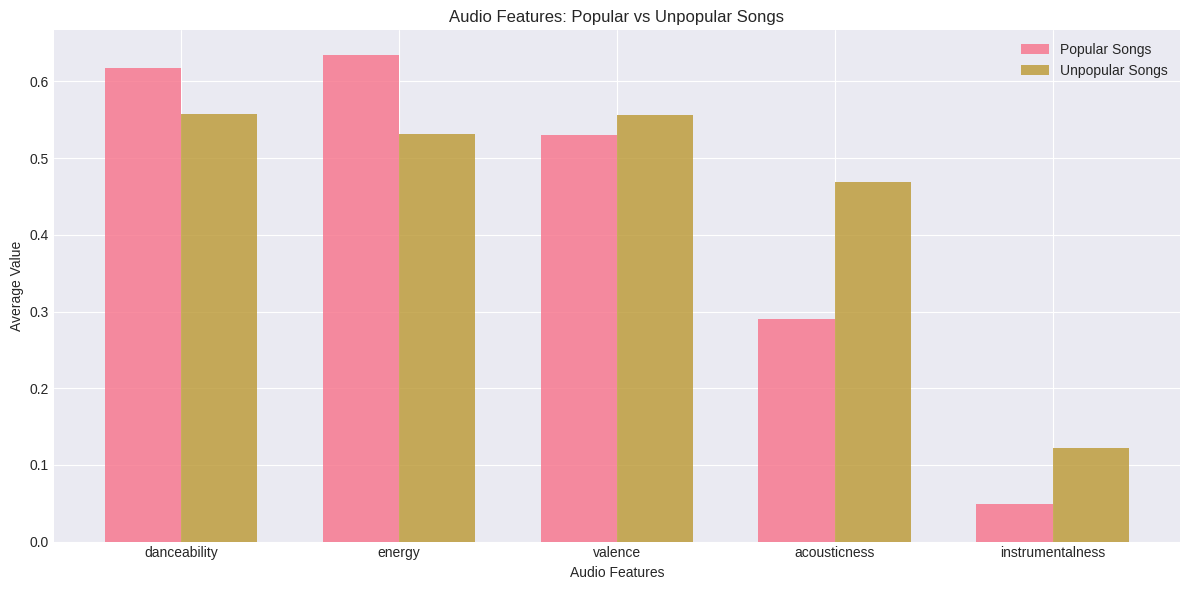

In [63]:
print("\nPopularity Analysis:\n")

# Find characteristics of popular songs (popularity > 50)
popular_songs = tracks_clean.filter(col("popularity") > 50)
unpopular_songs = tracks_clean.filter(col("popularity") <= 50)

# Compare audio features
features_comparison = []
for feature in audio_features:
    pop_avg = popular_songs.select(avg(feature)).collect()[0][0]
    unpop_avg = unpopular_songs.select(avg(feature)).collect()[0][0]
    features_comparison.append({
        'feature': feature,
        'popular_avg': pop_avg,
        'unpopular_avg': unpop_avg,
        'difference': pop_avg - unpop_avg
    })

comparison_df = pd.DataFrame(features_comparison)

# Plot comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(features_comparison))
width = 0.35

plt.bar(x - width/2, comparison_df['popular_avg'], width, label='Popular Songs', alpha=0.8)
plt.bar(x + width/2, comparison_df['unpopular_avg'], width, label='Unpopular Songs', alpha=0.8)

plt.xlabel('Audio Features')
plt.ylabel('Average Value')
plt.title('Audio Features: Popular vs Unpopular Songs')
plt.xticks(x, comparison_df['feature'])
plt.legend()
plt.tight_layout()
plt.show()

   - **5-7 Advanced Analytics Using Window Function (Top 10% Most Popular Songs by Decade)**

In [66]:
# Calculate percentile ranks for popularity within each year
window_spec = Window.partitionBy("release_year").orderBy("popularity")

tracks_ranked = tracks_clean.withColumn(
    "popularity_percentile",
    percent_rank().over(window_spec) * 100
)

# Find top 10% most popular songs per decade
top_songs_by_decade = tracks_ranked \
    .filter(col("popularity_percentile") >= 90) \
    .groupBy("release_decade") \
    .agg(
        count("*").alias("top_10_percent_count"),
        avg("energy").alias("avg_energy_top_songs"),
        avg("valence").alias("avg_valence_top_songs"),
        collect_list("name").alias("sample_songs")
    ) \
    .orderBy("release_decade")

print("Top 10% Most Popular Songs by Decade:")
top_songs_data = top_songs_by_decade.toPandas()
for _, row in top_songs_data.iterrows():
    print(f"\n{int(row['release_decade'])}s:")
    print(f"  Count: {row['top_10_percent_count']}")
    print(f"  Avg Energy: {row['avg_energy_top_songs']:.3f}")
    print(f"  Avg Valence: {row['avg_valence_top_songs']:.3f}")
    print(f"  Sample: {row['sample_songs'][:3]}")  # Show first 3 songs

Top 10% Most Popular Songs by Decade:

1920s:
  Count: 631
  Avg Energy: 0.263
  Avg Valence: 0.613
  Sample: ['Tu Verras Montmartre', 'Rum and coca cola', 'Nuits De Chine']

1930s:
  Count: 1201
  Avg Energy: 0.283
  Avg Valence: 0.550
  Sample: ['Just A Dream', 'Worrying You Off My Mind', 'Stop and Listen Blues # 2 - Live']

1940s:
  Count: 1580
  Avg Energy: 0.276
  Avg Valence: 0.500
  Sample: ['Lieder ohne Worte: Spring Song, Op. 62, No. 6', '台灣小調', '如果沒有你']

1950s:
  Count: 3227
  Avg Energy: 0.312
  Avg Valence: 0.523
  Sample: ['All Over Nothing At All', 'Muskrat Ramble', "I'll Remember April"]

1960s:
  Count: 4499
  Avg Energy: 0.427
  Avg Valence: 0.573
  Sample: ['Walking Through New Orleans', 'Carnival of the Animals, R. 125: Pianists', 'You Always Hurt the One You Love']

1970s:
  Count: 5931
  Avg Energy: 0.539
  Avg Valence: 0.596
  Sample: ["Surf's Up - Remastered 2009", 'Waltz for Debby', 'Oh Yoko! - Ultimate Mix']

1980s:
  Count: 7786
  Avg Energy: 0.612
  Avg Valen

   - **5-8 Feature Enginering For ML**

In [67]:
# creating interaction features
tracks_ml = tracks_clean \
    .withColumn("energy_danceability", col("energy") * col("danceability")) \
    .withColumn("valence_energy", col("valence") * col("energy")) \
    .withColumn("acoustic_instrumental", col("acousticness") * col("instrumentalness"))

# Normalize audio features (0-1 scale, except those already normalized)
from pyspark.ml.feature import MinMaxScaler, VectorAssembler

# Assemble features into vector
feature_cols = ['duration_minutes', 'loudness', 'tempo']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
tracks_assembled = assembler.transform(tracks_ml)

# Scale features
scaler = MinMaxScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(tracks_assembled)
tracks_scaled = scaler_model.transform(tracks_assembled)

print("Sample of engineered features:")
tracks_scaled.select("name", "energy_danceability", "valence_energy", "scaled_features") \
    .show(5, truncate=False)


Sample of engineered features:
+-----------------------------------+--------------------+--------------------+------------------------------------------------------------+
|name                               |energy_danceability |valence_energy      |scaled_features                                             |
+-----------------------------------+--------------------+--------------------+------------------------------------------------------------+
|Carve                              |0.2870249868988992  |0.056515000895261736|[0.022001495247249814,0.7137481607040128,0.4255644685565119]|
|Capítulo 2.16 - Banquero Anarquista|0.18278500607252113 |0.17226499997138944 |[0.016874933247890633,0.5791727906634327,0.414029507348968] |
|Vivo para Quererte - Remasterizado |0.07681799789142607 |0.0808889982537031  |[0.031720602371034926,0.5937958843897163,0.5293346524781188]|
|El Prisionero - Remasterizado      |0.030366600760185714|0.037556201194870464|[0.03086617537114173,0.4900728033684414,0.68

   - **5-9 Outlier Detection**

In [68]:
print("\nOutlier Detection:\n")

# Detect outliers using IQR method for key features
def detect_outliers(df, column):
    """Detect outliers using IQR method"""
    quantiles = df.select(
        expr(f"percentile_approx({column}, 0.25)").alias("Q1"),
        expr(f"percentile_approx({column}, 0.75)").alias("Q3")
    ).collect()[0]

    Q1 = quantiles["Q1"]
    Q3 = quantiles["Q3"]
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df.filter(
        (col(column) < lower_bound) | (col(column) > upper_bound)
    )

    return outliers, lower_bound, upper_bound

# Check for duration outliers
duration_outliers, low, high = detect_outliers(tracks_clean, "duration_minutes")
print(f"Duration outliers (< {low:.2f} or > {high:.2f} minutes):")
print(f"Count: {duration_outliers.count()}")
duration_outliers.select("name", "artists_cleaned", "duration_minutes") \
    .orderBy(col("duration_minutes").desc()) \
    .show(10)



Outlier Detection:

Duration outliers (< 0.70 or > 6.62 minutes):
Count: 26678
+--------------------+--------------------+----------------+
|                name|     artists_cleaned|duration_minutes|
+--------------------+--------------------+----------------+
|โครงสร้างแห่งสิ่ง...|         ท่านพุทธทาส|           93.69|
|Brown Noise - 90 ...|       Sound Dreamer|           90.06|
|New Year's Eve 20...|     Various Artists|           84.04|
|       Surah Al-Araf|Sheikh Mishary Ra...|           83.25|
|Tech House The Ye...|           Monoteque|           81.07|
|6 Years of 1980 R...|           Dan McKie|            80.0|
|       Surah An-Nisa|Sheikh Mishary Ra...|           79.95|
|Monster Tunes Yea...|         Mark Eteson|           79.88|
|Digital Punk: Unl...|     Various Artists|           79.78|
|Alltum Yearmix 20...|         John Clarcq|           79.59|
+--------------------+--------------------+----------------+
only showing top 10 rows

